# Load Packages and Data

We are using data from UC Irvine Machine Learning Repository. The data is aimed at the case of customer's default payments in Taiwan and compared the predictive accuracy of probability.

In [2]:
from ucimlrepo import fetch_ucirepo
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
import sklearn 

In [3]:
dataset = fetch_ucirepo(id=350)

X = dataset.data.features
y = dataset.data.targets

print(type(X))
print(type(y))
print(X.shape)
print(y.shape)

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
(30000, 23)
(30000, 1)


In [4]:
X.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X14,X15,X16,X17,X18,X19,X20,X21,X22,X23
0,20000,2,2,1,24,2,2,-1,-1,-2,...,689,0,0,0,0,689,0,0,0,0
1,120000,2,2,2,26,-1,2,0,0,0,...,2682,3272,3455,3261,0,1000,1000,1000,0,2000
2,90000,2,2,2,34,0,0,0,0,0,...,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000
3,50000,2,2,1,37,0,0,0,0,0,...,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000
4,50000,1,2,1,57,-1,0,-1,0,0,...,35835,20940,19146,19131,2000,36681,10000,9000,689,679


In [5]:
y.head()

,Y
0,1
1,1
2,0
3,0
4,0


In [6]:
X.columns

Index(['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11',
       'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'X19', 'X20', 'X21',
       'X22', 'X23'],
      dtype='object')

We note that the columns are arbitrarily named, so we rename them using their definitions as found on the website.

In [7]:
column_mapping = {
    "X1": "LIMIT_BAL",
    "X2": "SEX",
    "X3": "EDUCATION",
    "X4": "MARRIAGE",
    "X5": "AGE",
    "X6": "PAY_0",
    "X7": "PAY_2",
    "X8": "PAY_3",
    "X9": "PAY_4",
    "X10": "PAY_5",
    "X11": "PAY_6",
    "X12": "BILL_AMT1",
    "X13": "BILL_AMT2",
    "X14": "BILL_AMT3",
    "X15": "BILL_AMT4",
    "X16": "BILL_AMT5",
    "X17": "BILL_AMT6",
    "X18": "PAY_AMT1",
    "X19": "PAY_AMT2",
    "X20": "PAY_AMT3",
    "X21": "PAY_AMT4",
    "X22": "PAY_AMT5",
    "X23": "PAY_AMT6",
}

X = X.rename(columns=column_mapping)
y = y.rename(columns={"Y": "DEFAULT"})
print(X.columns.tolist())
print(y.columns.tolist())

['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
['DEFAULT']


## Check Data Quality Issues

In [8]:
credit_data = pd.concat([X,y], axis=1) # join data with its target to analyse
credit_data['EDUCATION'].value_counts()


EDUCATION
2    14030
1    10585
3     4917
5      280
4      123
6       51
0       14
Name: count, dtype: int64

We note that Education has numbers 0, 5, 6 which are not described by the data set. We want to explore what these other values are in order to decide what should be done with them.

In [9]:
credit_data.groupby('EDUCATION')['DEFAULT'].mean().sort_values(ascending=False)

EDUCATION
3    0.251576
2    0.237349
1    0.192348
6    0.156863
5    0.064286
4    0.056911
0    0.000000
Name: DEFAULT, dtype: float64

From this we see that each category (0, 5 and 6) behave differently and can therefore not be grouped with any other categories. If we keep these categories the model may learn a false pattern from an undocumented category. This can be seen even more in EDUCATION=0, which has a 0% default rate. These rows will be dropped. 


In [10]:
credit_data['MARRIAGE'].value_counts()

MARRIAGE
2    15964
1    13659
3      323
0       54
Name: count, dtype: int64

Here we also note an undocumented category "0". Let's decide what to do with it in the same way.

In [11]:
credit_data.groupby('MARRIAGE')['DEFAULT'].mean().sort_values(ascending=False)

MARRIAGE
3    0.260062
1    0.234717
2    0.209283
0    0.092593
Name: DEFAULT, dtype: float64

We can't determine what this category represents, and it behaves differently from all documented categories, so keeping it risks the model learning a false pattern. 

In [12]:
credit_data['SEX'].value_counts()

SEX
2    18112
1    11888
Name: count, dtype: int64

Values are all good here (1= male, 2=female).

Now, we drop the rows which are in the undocumented categories. Let's check if there is any overlap between the two conditions first so we now how many rows we should be left with.

In [13]:
(credit_data['MARRIAGE'] == 0).sum() + credit_data['EDUCATION'].isin([0, 5, 6]).sum() 

np.int64(399)

All together, there are 399 instances of uncategorised items. Let's check these are unique cases or if they overlap. 

In [14]:
((credit_data['MARRIAGE'] == 0) & (credit_data['EDUCATION'].isin([0, 5, 6]))).sum()

np.int64(0)

There is 0 overlap between the two conditions. We now remove the rows using pandas negation.

In [15]:
df_clean = credit_data[~(credit_data['MARRIAGE'].isin([0])) & ~(credit_data['EDUCATION'].isin([0, 5, 6]))]

In [25]:
df_clean.shape

(29601, 24)

We had 30,000 rows to start and removed 399 so this shape makes sense. 

In [35]:
df_clean.columns

Index(['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2',
       'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'DEFAULT'],
      dtype='object')

I will now check for any missing data.

In [40]:
df_clean.isna().sum().sort_values(ascending=False)

LIMIT_BAL    0
SEX          0
EDUCATION    0
MARRIAGE     0
AGE          0
PAY_0        0
PAY_2        0
PAY_3        0
PAY_4        0
PAY_5        0
PAY_6        0
BILL_AMT1    0
BILL_AMT2    0
BILL_AMT3    0
BILL_AMT4    0
BILL_AMT5    0
BILL_AMT6    0
PAY_AMT1     0
PAY_AMT2     0
PAY_AMT3     0
PAY_AMT4     0
PAY_AMT5     0
PAY_AMT6     0
DEFAULT      0
dtype: int64

There is no missing data so we can move on. 

# EDA 

1. What is the class balance of the target?
2. How do individual features relate to the target?
3. Are there outliers, and how extreme are they?


We will split the feature into four different groups to simplify the analysis process. 

In [141]:
defaulters = df_clean[(df_clean['DEFAULT'] == 1)]
non_defaulters = df_clean[(df_clean['DEFAULT'] == 0)]

basic_info_cat = [ 'SEX', 'EDUCATION', 'MARRIAGE']
basic_info_num = ['LIMIT_BAL', 'AGE']
pay_records = [ 'PAY_0', 'PAY_2','PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
bill_amts = ['BILL_AMT1', 'BILL_AMT2','BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
pay_amts = ['PAY_AMT1','PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

Start with checking the class balance as it gives the context to interpret everything else correctly. If we have high class imbalance, it would be hard to tell what is a meaningful patterns of an artefact of having very few defaulters. 

In [102]:
df_clean['DEFAULT'].describe()

count    29601.000000
mean         0.223134
std          0.416355
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: DEFAULT, dtype: float64

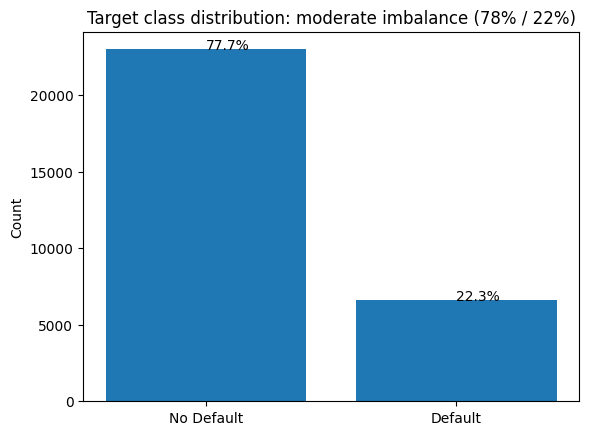

In [94]:
counts = df_clean['DEFAULT'].value_counts()
total = counts.sum()


plt.bar(counts.index, counts.values)
plt.title('Target class distribution: moderate imbalance (78% / 22%)')

plt.xticks([0, 1], ['No Default', 'Default'])

plt.ylabel('Count')

for i in range(len(counts.index)):
    plt.text(counts.index[i], counts.values[i], f"{counts.values[i] / total * 100:.1f}%")


There is an imbalance but it is only moderate. A dummy model would score around 78% accuracy. Recall is of high importance here as missing a true defaulter is more costly than wrongly flagging a non-defaulter. 

In [108]:
df_clean.groupby(basic_info_cat[0])['DEFAULT'].mean()

SEX
1    0.243572
2    0.209689
Name: DEFAULT, dtype: float64

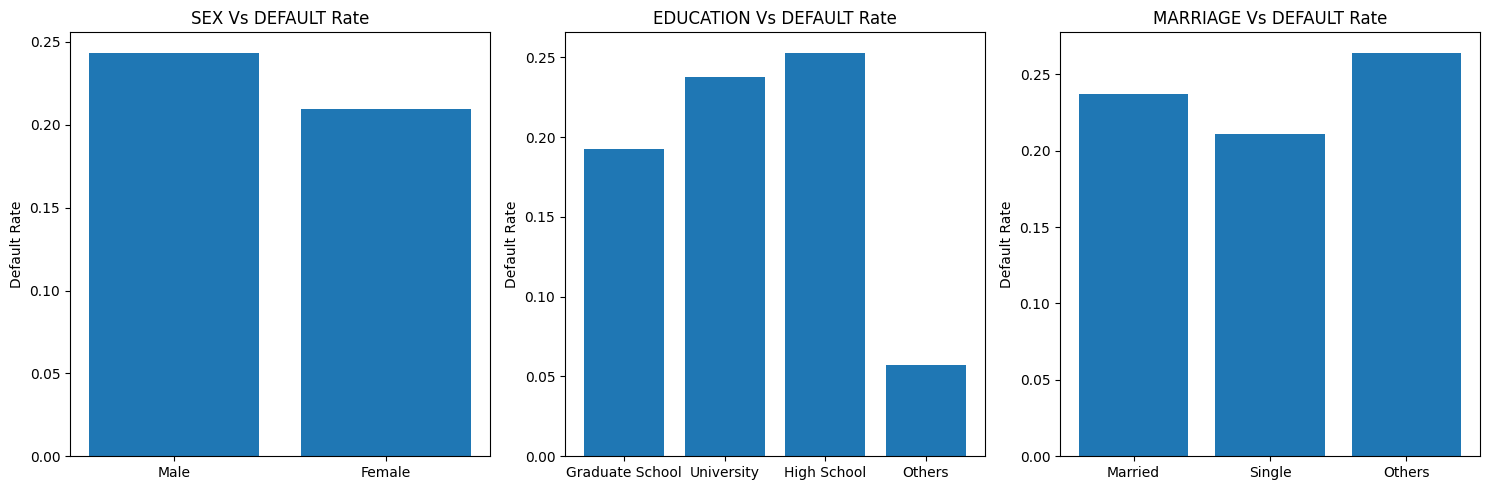

In [122]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sex_labels = {1 : 'Male', 2: 'Female'}
edu_labels = {1 : "Graduate School", 2: 'University',3 : 'High School', 4 : 'Others'}
marriage_labels = {1 : 'Married', 2 : 'Single', 3 : 'Others'}

cat_labels = [sex_labels, edu_labels, marriage_labels]

for i in range(len(basic_info_cat)):
    default_rate = df_clean.groupby(basic_info_cat[i])['DEFAULT'].mean()
    axes[i].bar(default_rate.index, default_rate.values)
    axes[i].set_title(basic_info_cat[i] + ' Vs DEFAULT Rate')
    axes[i].set_ylabel('Default Rate')
    axes[i].set_xticks(default_rate.index)
    axes[i].set_xticklabels([cat_labels[i][num] for num in default_rate.index])
plt.tight_layout()

Note that overall, males default more then females. This difference is around 3-2%. For education we see a trend that the higher the education level the less likely the person is to default. There is a very large gap between these categories and "others". In regards to marriage we see that single people are least likely to default with a slight increase in the default rate for married individuals and the "others" category is the highest. 

These observations are descriptive and have not been tested for significance. 

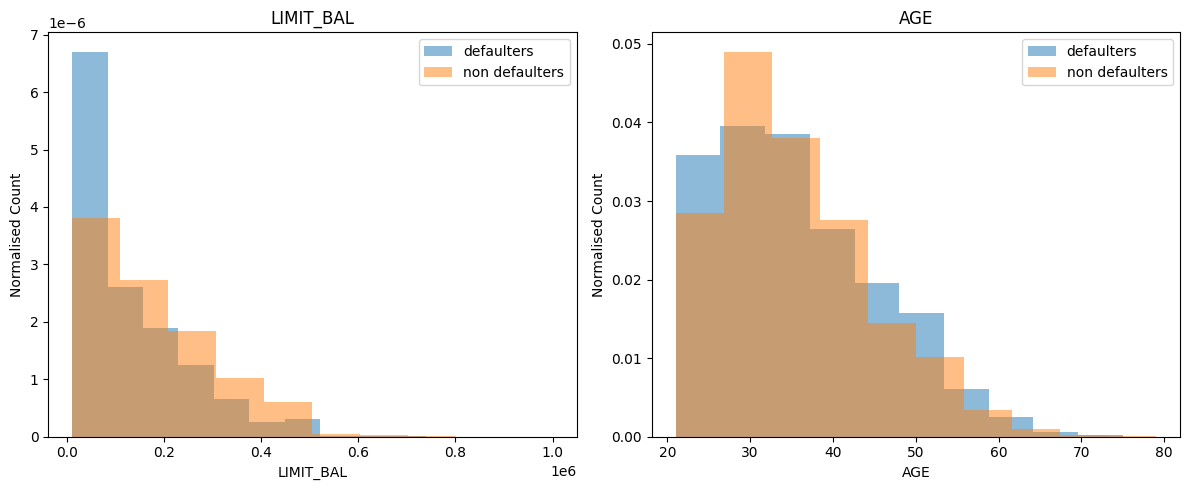

In [219]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    

for i in range(len(basic_info_num)):
    axes[i].hist(defaulters[basic_info_num[i]], alpha=0.5, density=True, label='defaulters')
    axes[i].hist(non_defaulters[basic_info_num[i]], alpha=0.5, density=True, label='non defaulters')
    axes[i].set_title(basic_info_num[i])
    axes[i].set_xlabel(basic_info_num[i])
    axes[i].set_ylabel('Normalised Count')
    axes[i].legend()
    
plt.tight_layout()
plt.show()



We note from LIMIT_BAL that people with lower credit limit are more likely to default. This makes sense as lower credit is associated with higher default risk. This looks like it could be a useful predictor. 

For the age plot we note that people in their 20s are marginally more likely to default. This does not appear as predictive as limit_bal. 

These descriptions are based on graphical observations and have not been tested for significance. 

In [158]:
df_clean['PAY_0'].value_counts()

PAY_0
 0    14499
-1     5633
 1     3662
-2     2708
 2     2640
 3      320
 4       76
 5       24
 8       19
 6       11
 7        9
Name: count, dtype: int64

We note that there are two undocumented values (0 and -2). We check their behavior with regards to their default rate to see if we can assume that 0 is No Delay and -2 is Paid Early. 

In [220]:
df_clean.groupby(pay_records)['DEFAULT'].mean().sort_values(ascending=False)

PAY_0  PAY_2  PAY_3  PAY_4  PAY_5  PAY_6
-2     -2     -2     -1     2       0       1.0
 4      4      3      2     2       3       1.0
               4      3     2       0       1.0
 6      5      4      4     3       2       1.0
 4      4      4      3     2       2       1.0
                                           ... 
-2     -2     -2      2     2      -1       0.0
                     -1     4       3       0.0
                            2      -1       0.0
 3      3      4      4     5       5       0.0
-2     -2     -2     -2     0       0       0.0
Name: DEFAULT, Length: 1102, dtype: float64

The default rate between -2, 0 and 1 is much different to the jump ay 1+ months delay. This confirms the pattern that we can group -2 and 0 with -1 rather then with the late payment categories. 

In [162]:
pay_labels = {-2 : "Paid early", -1 : "Pay duly", 0 : 'No delay', 1: "1 month delay", 2 : '2 month delay', 3: '3 month delay', 4: '4 month delay', 5 : '5 month delay', 
              6 : '6 month delay', 7 : '7 month delay', 8: '8 month delay'}

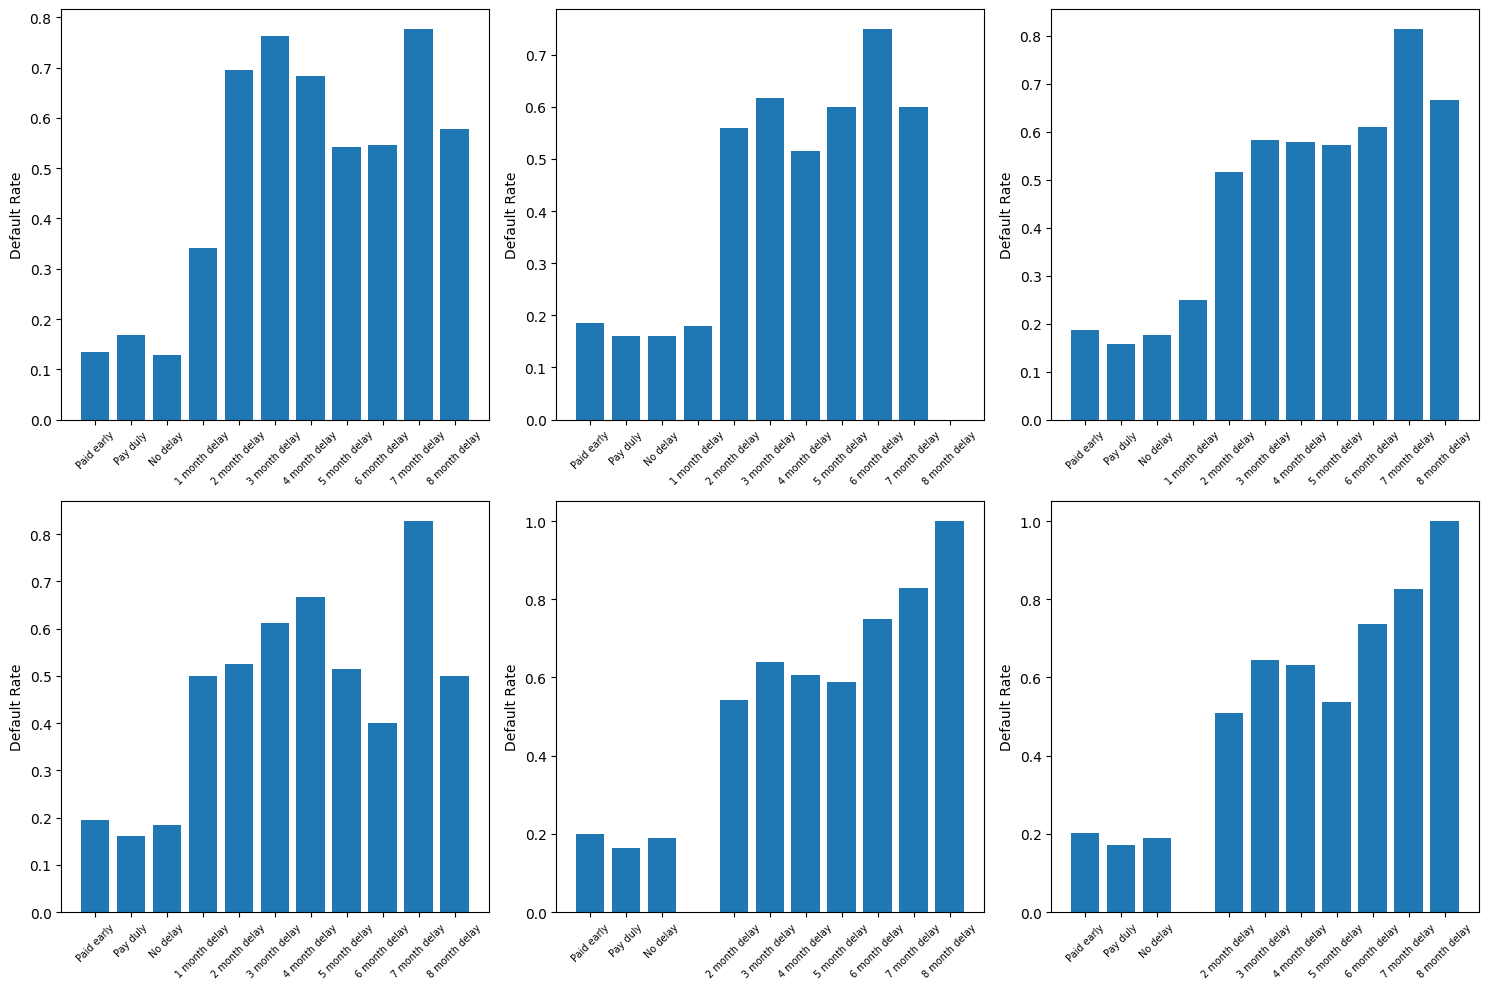

In [184]:
# plot bar plots for monthly repayment 
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i in range(len(pay_records)):
    pay_default_rate = df_clean.groupby(pay_records[i])['DEFAULT'].mean()
    axes[i].bar(pay_default_rate.index, pay_default_rate.values)
    axes[i].set_xticks(pay_default_rate.index)
    axes[i].set_xticklabels([pay_labels[num] for num in pay_default_rate.index], fontsize=7)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_ylabel('Default Rate')
plt.tight_layout()
plt.show()
    

All plots follow a similar pattern where the default rate is low until it hits 1+ months delay. After this the default rate increases rapidly. This shows repayment status could be a strong predictor of default rate. We also note that most of the plots spike around the 7th or 8th month. Since plots share similar patters it suggests they may be correlated with each other. 

Therefore, repayment status features may be candidates for aggregation due to high inter-correlation.

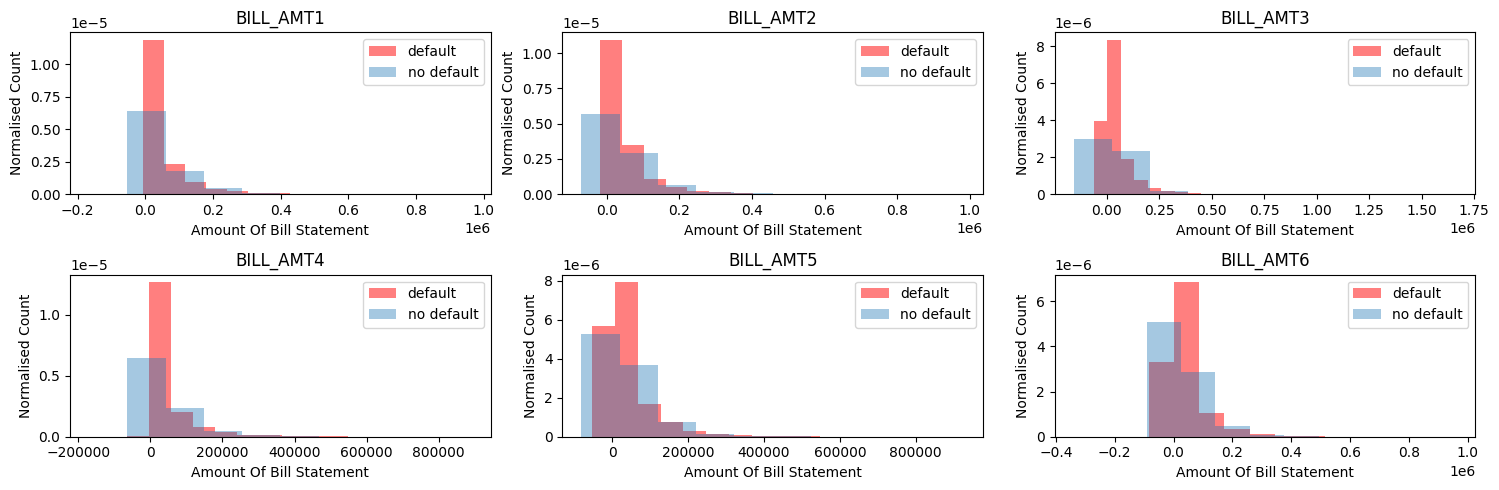

In [216]:
fig, axes = plt.subplots(2, 3, figsize=(15, 5))
axes = axes.flatten()

for i in range(len(bill_amts)):
    axes[i].hist(defaulters[bill_amts[i]], alpha=0.5, label='default', color='red', density=True)
    axes[i].hist(non_defaulters[bill_amts[i]], alpha =0.4, label='no default', density=True)
    axes[i].set_ylabel('Normalised Count')
    axes[i].set_title(bill_amts[i])
    axes[i].set_xlabel("Amount Of Bill Statement")

    axes[i].legend()
plt.tight_layout()
plt.show()

Bill amounts are heavily right-skewed with extreme outliers, and negative values exist representing credit balances. We see that defaulters tend to have lower bill amounts, possibly because they have lower credit limits. These features may be correlated. 

Note that models like logistic regressions, SVM, and KNN will be affected. Tree-based models like random forest and gradient boosting are more robust. 

In [201]:
df_clean[bill_amts].describe()

,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6
count,29601.000000,29601.000000,2.960100e+04,29601.000000,29601.000000,29601.000000
mean,50957.432012,48942.189554,4.680320e+04,43122.554204,40235.545184,38858.449816
std,73370.242404,70923.985151,6.912389e+04,64196.383913,60699.344884,59519.893043
min,-165580.000000,-69777.000000,-1.572640e+05,-170000.000000,-81334.000000,-339603.000000
25%,3528.000000,2970.000000,2.652000e+03,2329.000000,1780.000000,1278.000000
50%,22259.000000,21050.000000,2.003500e+04,19005.000000,18091.000000,17118.000000
75%,66623.000000,63497.000000,5.983000e+04,54271.000000,50072.000000,49121.000000
max,964511.000000,983931.000000,1.664089e+06,891586.000000,927171.000000,961664.000000


The skew is clear here as the mean and median of each have a large disparity. We also not the big gap between 75% and the max values. 

In [203]:
df_clean[pay_amts].describe()

,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
count,29601.000000,2.960100e+04,29601.000000,29601.000000,29601.000000,29601.000000
mean,5649.560319,5.894788e+03,5198.415898,4828.659268,4795.032735,5181.326374
std,16568.264941,2.308919e+04,17580.914806,15711.057992,15244.217154,17657.260739
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000
25%,1000.000000,8.250000e+02,390.000000,298.000000,259.000000,138.000000
50%,2100.000000,2.007000e+03,1800.000000,1500.000000,1500.000000,1500.000000
75%,5005.000000,5.000000e+03,4500.000000,4014.000000,4042.000000,4000.000000
max,873552.000000,1.684259e+06,896040.000000,621000.000000,426529.000000,528666.000000


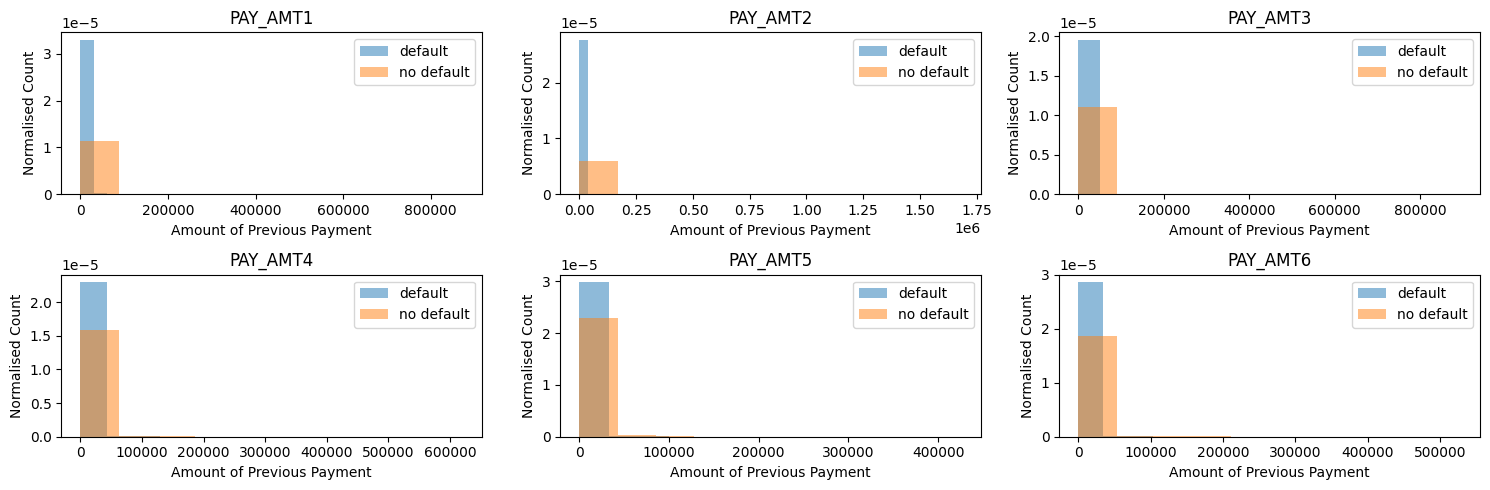

In [217]:
fig, axes = plt.subplots(2, 3, figsize=(15, 5))

axes = axes.flatten()

for i in range(len(pay_amts)):
    axes[i].hist(defaulters[pay_amts[i]], density=True, alpha=0.5, label = 'default')
    axes[i].hist(non_defaulters[pay_amts[i]], density=True, alpha=0.5, label = 'no default')
    axes[i].legend()
    axes[i].set_ylabel('Normalised Count')
    axes[i].set_xlabel('Amount of Previous Payment')
    axes[i].set_title(pay_amts[i])

plt.tight_layout()
plt.show()

Previously paid amounts contain outliers, which skews the data. This is likely related with the other features. People with lower credit have lower bill amounts and therefore lower payment amounts. All these features tell a similar story. This is something we should investigate (multicollinearity) when we get to feature selection. 

### EDA Summary

1. Repayment status features are the strongest predictors - the jump at 1+ months delay is dramatic
2. Bill and payment amount features are heavily right-skewed with extreme outliers - preprocessing will be needed for non-tree models
3. Features within groups appear highly correlated - multicollinearity is worth investigating at modelling time 

Saving the final clean data to /data/processed for use in modelling pipeline:

In [224]:
df_clean.to_csv('../data/processed/df_clean.csv', index=False)